# 04-04 - Outlier Detection & Treatment

**Phase:** 04 - Data Analysis & Preparation

**Difficulty:** 2/3 | **Priority:** 2/2

**Status:** VERIFIED

---

## 1. What Are We Solving?

**Outliers** are data points that differ significantly from the rest. They can be genuine (rare events) or errors (typos, sensor failures). Detecting and handling them correctly is crucial because they can skew statistics and models.

## 2. Why Does This Matter?

Outliers can distort the mean, inflate variance, and destabilize models. But removing genuine outliers loses real information. You need to detect them and decide whether to keep, cap, or remove.

## 3. Prerequisites

- Unit 03.1 (Descriptive statistics)
- Unit 04.1 (EDA)

## 4. Learning Objectives

By the end of this notebook, you should be able to:
- [ ] Detect outliers using the IQR method
- [ ] Detect outliers using the z-score method
- [ ] Visualize outliers with boxplots and scatter plots
- [ ] Decide whether to keep, cap, or remove outliers
- [ ] Understand the impact of outliers on statistics
## 5. Mental Model

**Mental Model:** Outliers are like that one person who always shows up to the party an hour early or three hours late. They're real people, but they skew the vibe. You need to decide: is this person interesting and worth keeping (a genuine extreme value), or are they causing chaos (an error)? The IQR method is your bouncer — it flags anyone too far from the crowd.

Key: understand the data before you model it.


## 2a. Decision Guidance

| Situation | What to Do | Why |
|-----------|------------|-----|
| Outlier is a data entry error | Remove or correct | It's garbage data |
| Outlier is genuine but extreme | Use robust scaling or transforms | Preserves information |
| Many outliers in one feature | Consider log transform | Reduces skewness |
| Outliers only in training set | Cap at 99th percentile | Prevents overfitting to extremes |
| Outliers are the target signal | Keep them — they're important | Domain-dependent |


## 2b. Common Mistakes to Avoid

- Removing all outliers without investigating first
- Using mean/std for outlier detection (use IQR or median)
- Applying outlier treatment before train/test split
- Removing outliers that represent real phenomena
- Not visualizing outliers before deciding on treatment


## 6. Create Data with Outliers

Let's create a dataset with a few outliers.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
data = np.random.normal(50, 10, 200)
# Add outliers
data = np.append(data, [100, 110, 5, 120])

print(f"Data: {len(data)} points")
print(f"Mean: {np.mean(data):.2f}")
print(f"Median: {np.median(data):.2f}")
print(f"Std: {np.std(data, ddof=1):.2f}")
print("\nThe outliers pull the mean up but affect the median less.")


Data: 204 points
Mean: 50.26
Median: 50.09
Std: 12.22

The outliers pull the mean up but affect the median less.


## 7. Visualize Outliers

A boxplot shows outliers as points beyond the whiskers.


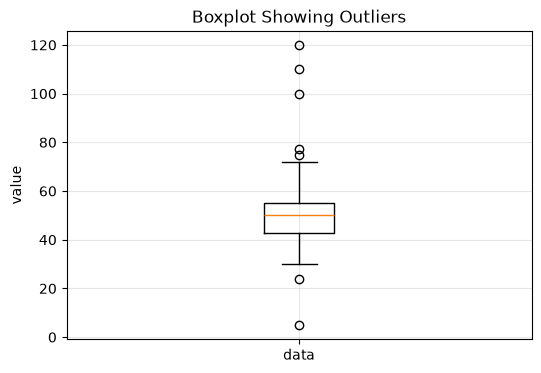

Points beyond the whiskers are flagged as outliers.


In [2]:
# Boxplot
plt.figure(figsize=(6, 4))
plt.boxplot(data, tick_labels=["data"])
plt.title("Boxplot Showing Outliers")
plt.ylabel("value")
plt.grid(True, alpha=0.3)
plt.show()
print("Points beyond the whiskers are flagged as outliers.")


## 8. IQR Method

The **IQR (interquartile range)** method flags points outside `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.


In [3]:
# IQR method
q1 = np.percentile(data, 25)
q3 = np.percentile(data, 75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers_iqr = data[(data < lower) | (data > upper)]

print(f"Q1: {q1:.2f}, Q3: {q3:.2f}, IQR: {iqr:.2f}")
print(f"Bounds: [{lower:.2f}, {upper:.2f}]")
print(f"Outliers detected: {len(outliers_iqr)}")
print(f"Outlier values: {outliers_iqr}")


Q1: 42.95, Q3: 55.27, IQR: 12.32
Bounds: [24.47, 73.75]
Outliers detected: 7
Outlier values: [ 23.80254896  74.63242112  77.20169167 100.         110.
   5.         120.        ]


## 9. Z-Score Method

The **z-score** measures how many standard deviations a point is from the mean. Points with `|z| > 3` are outliers.


In [4]:
# Z-score method
z_scores = np.abs(stats.zscore(data))
outliers_z = data[z_scores > 3]

print(f"Z-scores > 3: {len(outliers_z)} outliers")
print(f"Outlier values: {outliers_z}")
print("\nBoth methods detect the extreme values.")


Z-scores > 3: 4 outliers
Outlier values: [100. 110.   5. 120.]

Both methods detect the extreme values.


## 10. Impact of Outliers on Statistics

Outliers distort the mean and standard deviation. Let's compare statistics with and without outliers.


In [5]:
# Compare statistics with and without outliers
clean = data[(np.abs(stats.zscore(data)) <= 3)]

print("With outliers:")
print(f"  Mean: {np.mean(data):.2f}, Std: {np.std(data, ddof=1):.2f}")
print("Without outliers:")
print(f"  Mean: {np.mean(clean):.2f}, Std: {np.std(clean, ddof=1):.2f}")
print("\nOutliers inflate the std and shift the mean.")


With outliers:
  Mean: 50.26, Std: 12.22
Without outliers:
  Mean: 49.59, Std: 9.31

Outliers inflate the std and shift the mean.


## 11. Handling Outliers: Capping (Winsorizing)

**Capping** (winsorizing) replaces extreme values with the boundary values instead of removing them. This keeps the data point but limits its influence.


In [6]:
# Cap outliers at the IQR bounds
data_capped = np.clip(data, lower, upper)

print(f"Original mean: {np.mean(data):.2f}")
print(f"Capped mean: {np.mean(data_capped):.2f}")
print(f"Original std: {np.std(data, ddof=1):.2f}")
print(f"Capped std: {np.std(data_capped, ddof=1):.2f}")
print("\nCapping reduces the influence of outliers while keeping all rows.")


Original mean: 50.26
Capped mean: 49.81
Original std: 12.22
Capped std: 9.77

Capping reduces the influence of outliers while keeping all rows.


## 12. Failure Case: Removing Genuine Outliers

Not all outliers are errors. In fraud detection, the outliers ARE the interesting cases. Removing them destroys the signal.


In [7]:
# Fraud detection: outliers are the signal
np.random.seed(1)
normal = np.random.normal(100, 20, 1000)  # normal transactions
fraud = np.random.normal(500, 50, 10)     # fraudulent transactions (outliers)
all_tx = np.concatenate([normal, fraud])

z = np.abs(stats.zscore(all_tx))
flagged = all_tx[z > 3]
print(f"Total transactions: {len(all_tx)}")
print(f"True fraud cases: {len(fraud)}")
print(f"Flagged as outliers (z>3): {len(flagged)}")
print("\nIn fraud detection, outliers are the cases we WANT to find.")
print("Removing them would destroy the signal. Context matters!")


Total transactions: 1010
True fraud cases: 10
Flagged as outliers (z>3): 10

In fraud detection, outliers are the cases we WANT to find.
Removing them would destroy the signal. Context matters!


## 13. Debugging: Common Errors

- **Removing genuine outliers**: loses real information.
- **Using mean with outliers**: median is more robust.
- **Z-score on skewed data**: z-score assumes normality.
- **Not visualizing**: summary stats hide outliers.
- **Ignoring context**: an outlier may be the signal.

## 14. Real-World Considerations

- Always visualize before deciding.
- Consider whether outliers are errors or genuine.
- For skewed data, use IQR or robust methods.
- Document your outlier handling.

## 15. Common Mistakes

- Removing outliers without understanding them.
- Using z-score on non-normal data.
- Not checking the impact on the model.
- Treating all outliers the same.

## 16. When NOT to Use

- Don't remove outliers when they're the signal (fraud, anomalies).
- Don't use z-score for heavily skewed data.
- Don't remove outliers without checking the impact.

## 17. Challenge

A salary dataset has a few extreme values (CEOs). Decide whether to keep, cap, or remove them, and justify your choice.


In [8]:
# Challenge: handle CEO salaries
np.random.seed(3)
salaries = np.random.normal(60000, 15000, 500)
salaries = np.append(salaries, [500000, 800000, 1200000])  # CEO salaries

print(f"Mean salary: ${np.mean(salaries):,.0f}")
print(f"Median salary: ${np.median(salaries):,.0f}")
print("\nThe mean is inflated by CEO salaries; the median is robust.")

# Capping is often best for salaries - keeps the data but limits influence
q1 = np.percentile(salaries, 25)
q3 = np.percentile(salaries, 75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr
capped = np.clip(salaries, None, upper)

print(f"Cap at: ${upper:,.0f}")
print(f"Capped mean: ${np.mean(capped):,.0f}")
print("\nCapping limits the influence of CEO salaries while keeping all rows.")
print("This is often the best choice for salary data.")


Mean salary: $64,702
Median salary: $59,568

The mean is inflated by CEO salaries; the median is robust.
Cap at: $102,617
Capped mean: $60,344

Capping limits the influence of CEO salaries while keeping all rows.
This is often the best choice for salary data.


## 19. Knowledge Check

1. What is the IQR method and how does it define an outlier?
2. When should you keep outliers vs. remove them?
3. Why is the median more robust to outliers than the mean?
4. What is the danger of removing outliers from the training set but not the test set?
5. How do you distinguish between a genuine extreme value and a data error?

## 19. Teach-Back Questions

Explain to another person:

- The difference between IQR and z-score methods.
- Why context matters when handling outliers.
- When to keep, cap, or remove outliers.

## 20. Summary

You now understand outliers: how to detect them (IQR, z-score, visualization), their impact on statistics, and how to handle them (keep, cap, remove). You know that context determines the right approach.


## 21a. Exit Criteria

- [ ] I can visualize outliers with boxplots
- [ ] I can detect outliers using IQR and Z-score methods
- [ ] I can decide when to remove, cap, or keep outliers
- [ ] I can apply outlier treatment consistently to new data
- [ ] I can evaluate the impact of outlier treatment on model performance

## 21b. Next Step

Proceed to `04_05_feature_scaling_encoding.ipynb` to learn feature transformations.

## 22. Hands-On Practice

**Level 1 - Observation:** Create boxplots for all numeric features to spot outliers visually.

**Level 2 - Guided:** Calculate IQR bounds for one column and count outliers.

**Level 3 - Practice:** Apply the IQR method to flag outliers in multiple columns.

**Level 4 - Challenge:** Cap outliers at the 1st and 99th percentiles and compare distributions.

**Level 5 - Mastery:** Compare model performance with outlier removal vs. robust scaling vs. no treatment.

## 22. Verification Status

```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: numpy, pandas, matplotlib, scipy
OUTPUTS: PASS
LAST VERIFIED: 2026-08-28
```
